# Part 1: PCA — Dimensionality Reduction
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Tuesday — Visualising 10-Dimensional Data on a 2D Screen

Sarah has 10 customer features. She wants to look at the data on a chart. Charts have 2 dimensions. So she has to compress 10 dimensions into 2 — without losing the signal.

PCA does exactly that.

**By the end of this notebook you will be able to:**
- Apply PCA to standardised numerical features
- Read a scree plot and decide how many components to keep
- Project the data into 2D and look at the result
- Interpret what each principal component "means" by looking at its loadings

In [19]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — PCA ready")

✅ Libraries loaded — PCA ready


## Step 1 — Load + preprocess

Same preprocessing as L03/L04 (median impute + standard scale + one-hot encode).

### What is PCA, and why are we using it?

Our dataset has 10 customer features. That's 10 dimensions. You can't plot 10-dimensional data on a screen — a chart has 2 axes. PCA (**Principal Component Analysis**) is the standard tool for solving this problem: it finds a new set of axes (called **principal components**) that capture the most variation in the data, then lets you project the data onto just the first 2 or 3 of those axes for visualisation.

The key idea: **PCA finds the directions in which the data varies the most.** The first principal component (PC1) points in the direction of maximum variance. PC2 points in the next most variable direction that is perpendicular to PC1. And so on.

### What does "variance-based" mean?

PCA works by measuring how much the data spreads along each direction. "Variance" is just a number that quantifies spread — high variance means the data is stretched out along that direction; low variance means it's squished. PCA ranks directions by variance, so the first few components carry most of the information and the later ones are mostly noise.

**Critical:** Because PCA is comparing variances across features, those features must be on the same scale. A feature measured in pounds (0–500) would look far more variable than a feature measured in years (0–5), even if neither is actually more informative. That's why we MUST scale before fitting.

In [20]:
df = pd.read_csv("data/northstar_customers.csv")
features = df.drop(columns=["customer_id", "churned"])  # unsupervised — no labels

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])

X_processed = preprocessor.fit_transform(features)
feature_names_processed = preprocessor.get_feature_names_out()

print(f"Original features:    {features.shape[1]}  ({len(numeric_features)} numeric + {len(categorical_features)} categorical)")
print(f"After preprocessing:  {X_processed.shape[1]} columns  ({len(numeric_features)} scaled num + one-hot expansions)")

Original features:    10  (8 numeric + 2 categorical)
After preprocessing:  17 columns  (8 scaled num + one-hot expansions)


## Step 2 — Fit PCA with ALL components

We start by fitting PCA WITHOUT reducing — we just want to see the variance distribution across all components.

In [21]:
pca_full = PCA()  # no n_components → keeps everything
pca_full.fit(X_processed)

variance_df = pd.DataFrame({
    "component":              [f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))],
    "variance_explained":     pca_full.explained_variance_ratio_,
    "cumulative_variance":    np.cumsum(pca_full.explained_variance_ratio_),
})
print(variance_df.head(10).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

component  variance_explained  cumulative_variance
      PC1               0.111                0.111
      PC2               0.109                0.220
      PC3               0.109                0.328
      PC4               0.107                0.435
      PC5               0.107                0.542
      PC6               0.105                0.647
      PC7               0.104                0.752
      PC8               0.103                0.854
      PC9               0.043                0.897
     PC10               0.031                0.928


### Reading the table

| Column | What it means |
|---|---|
| `component` | The name of each principal component — PC1 is the direction of highest variance, PC2 the next, and so on |
| `variance_explained` | The fraction of total variance that this one component captures (0 to 1). PC1 = 0.111 means PC1 alone accounts for 11.1% of the variation in the data |
| `cumulative_variance` | Running total of variance explained by all components up to and including this one. Once this reaches 0.80, you've kept enough components to explain 80% of the original data's spread |

**What to look for:** In a highly compressible dataset, PC1 might capture 0.40–0.60 of variance on its own, meaning most variation lives along a single axis. Here PC1 only captures ~0.11, which tells us the 10 features are mostly independent — the variation is spread fairly evenly across many directions, and PCA can't compress the data dramatically without losing signal.

**<span style="color:green">[Opus 4.8]</span> What a "component" really is — clearing three mix-ups:**

The table above lists components, but it's easy to misread what a *component* is. There are **three different kinds of objects**, and they are NOT interchangeable:

| Object | Examples | What it is |
|---|---|---|
| **Original feature** | `age`, `tenure_months`, `support_tickets_quarter` | a raw input column (10 originals → **17** after one-hot encoding) |
| **Principal component (PC)** | PC1, PC2, … | a **NEW axis = a weighted blend of ALL 17 features** |
| **Name** | "Support Friction", "Transaction Activity" | a *human label* for a PC, read off its loadings in Step 5 |

**1. A PC is not a feature.** PC1 is *not* "age." Each PC is a recipe that mixes all 17 features, e.g.

```
PC1 ≈ 0.555·support_tickets + 0.452·age + 0.352·tenure − 0.432·review_polarity + …
```

`age` is just one ingredient (weight 0.452) — not the component itself. Think smoothie, not banana: the smoothie (PC1) *contains* the banana (age), but it is not the banana.

**2. There are 17 PCs, not 10.** 17 columns in → 17 PCs out. The table only shows 10 because the code calls `variance_df.head(10)`. The tell: `cumulative_variance` stops at **0.928**, yet it *must* reach 1.000 — the missing 0.072 lives in the hidden PC11–PC17. (Print `variance_df` without `.head(10)` to see all 17.)

**3. The full loadings are a 17×17 grid.** `pca.components_` has shape `(17 PCs, 17 features)` = **289** weights — one weight per feature, per PC. Step 5 prints only **2 of those 17 rows** (PC1, PC2), because that's all we keep for the 2D plot.

> **Bonus — why the tail PCs are ~0:** PC16 and PC17 carry essentially zero variance. That's the footprint of one-hot encoding: the dummy columns within each category always sum to 1, so they're linearly dependent, leaving a couple of "dead" directions with nothing left to explain. Near-zero tail components are a reliable sign of redundant/collinear input columns.

**<span style="color:green"><em>[Opus 4.8] — end of note</em></span>**

## ⏸️ Pause and Predict

Before plotting, predict:
- How many PCs would you need to capture 80% of total variance?
- What does it mean if the FIRST PC explains 0.20 of variance vs 0.50 of variance?

> *Sample:* If PC1 explains 0.50, the data has one strong "axis" — most variation lives in one direction. If PC1 explains 0.20, the variation is spread across many directions, meaning PCA doesn't compress much. Look at the variance_df above before scrolling.

## Step 3 — The scree plot

### What is a scree plot?

A scree plot is simply a bar chart of variance explained per component, in order from PC1 (most variance) to the last PC (least variance). The name comes from geology: "scree" is the loose rubble that collects at the base of a cliff. The plot tends to drop steeply for the first few components, then trail off into a flat rubble-like tail.

### Why do we look for the "elbow"?

The elbow is the point where the bars stop dropping steeply and start to flatten out. Components to the left of the elbow each add meaningful variance; components to the right add diminishing returns. Keeping only the components up to the elbow is a practical rule for choosing how many dimensions to retain — enough signal, without the noise.

The **cumulative variance** chart on the right is the complement: instead of asking "how much does each PC add?", it asks "how many PCs do I need to reach X% coverage?" The 80% and 90% threshold lines give you concrete answers.

Plot variance per component. Look for the "elbow" — the point where adding more components doesn't help much.

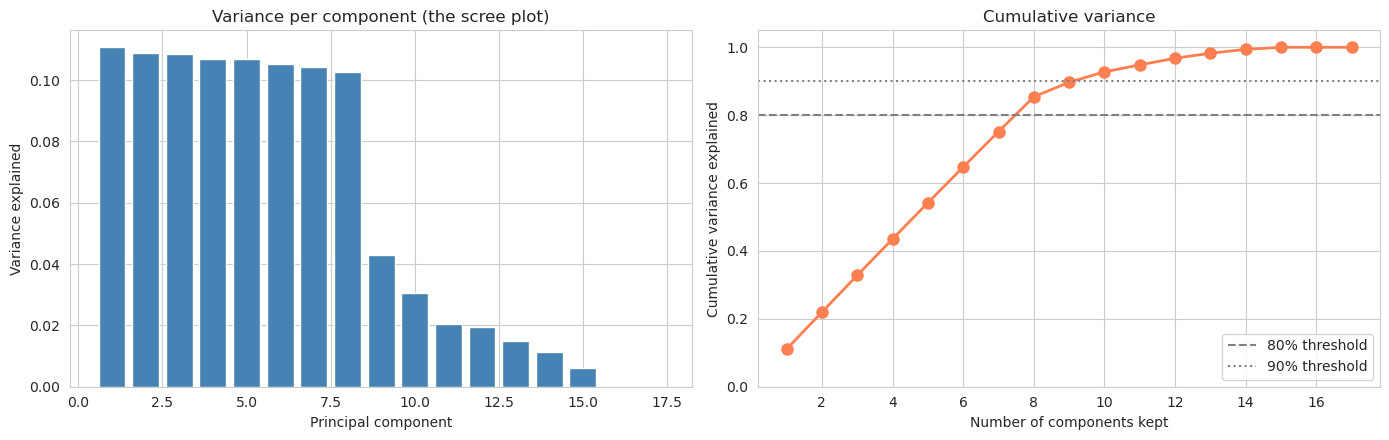

Components needed for 80% variance: 8
Components needed for 90% variance: 10


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: individual variance per PC
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_,
            color="steelblue", edgecolor="white")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained")
axes[0].set_title("Variance per component (the scree plot)")

# Right: cumulative variance
axes[1].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
             np.cumsum(pca_full.explained_variance_ratio_),
             "o-", linewidth=2, color="coral", markersize=8)
axes[1].axhline(0.8, color="gray", linestyle="--", label="80% threshold")
axes[1].axhline(0.9, color="gray", linestyle=":", label="90% threshold")
axes[1].set_xlabel("Number of components kept")
axes[1].set_ylabel("Cumulative variance explained")
axes[1].set_title("Cumulative variance")
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

n_for_80 = (np.cumsum(pca_full.explained_variance_ratio_) >= 0.80).argmax() + 1
n_for_90 = (np.cumsum(pca_full.explained_variance_ratio_) >= 0.90).argmax() + 1
print(f"Components needed for 80% variance: {n_for_80}")
print(f"Components needed for 90% variance: {n_for_90}")

### 💡 What you should notice

- The first few PCs capture most of the variance. After that the curve flattens.
- For VISUALISATION, we'll use the first 2 PCs (because we can plot in 2D). For PREPROCESSING, we'd keep more (typically enough for 80–90% variance).
- The fact that we need quite a few components for 80% tells us the features ARE mostly independent — confirming the correlation finding from NB 01.

## Step 4 — Project to 2D and plot

Now reduce to 2 components and plot the customers in PC1 × PC2 space. This is the view we'd put in front of Marcus on Friday.

Variance captured by 2 components: 22.0%



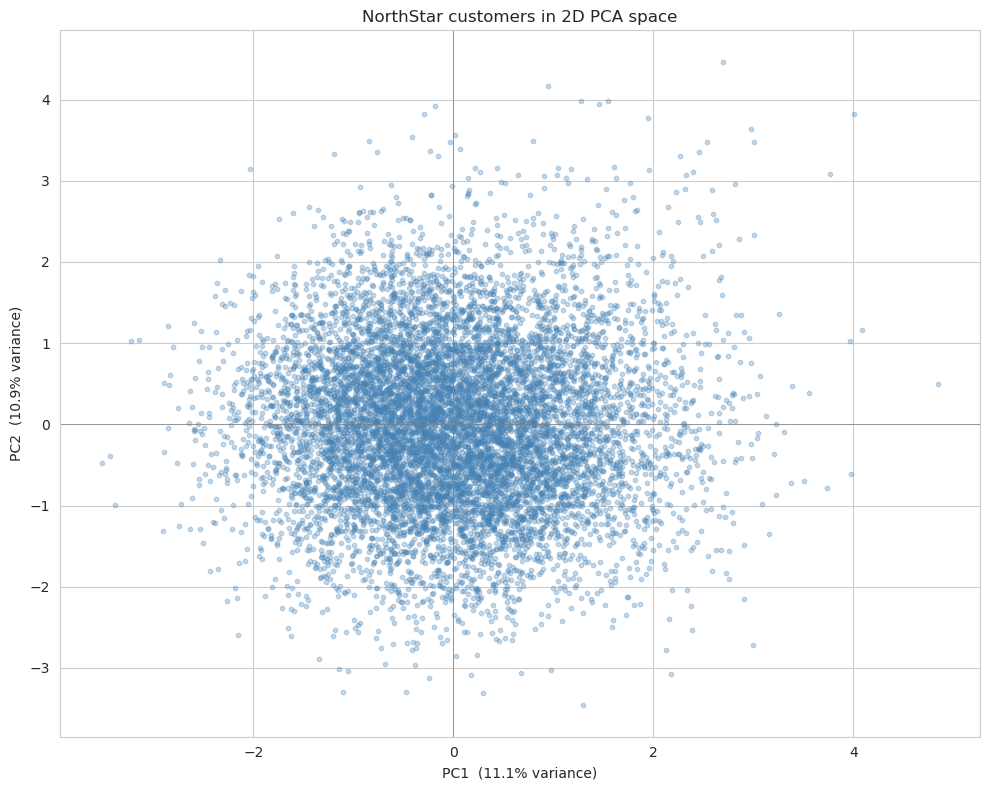

In [23]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_processed)

print(f"Variance captured by 2 components: {pca_2d.explained_variance_ratio_.sum():.1%}")
print()

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, s=10, color="steelblue")
ax.set_xlabel(f"PC1  ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2  ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("NorthStar customers in 2D PCA space")
ax.axvline(0, color="gray", linewidth=0.5)
ax.axhline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

### 💡 What you should notice

- The customers form a **single cloud** — no obvious clusters in the eyeball view.
- This is normal for real datasets. K-Means (tomorrow) will find centroids that group the cloud anyway — clusters often AREN'T visually obvious.
- The data has structure; PCA preserves the most variance-rich part of it. Whether that structure is *interpretable* depends on what's loading onto each PC — let's check.

## Step 5 — Interpret PC1 and PC2 by looking at the loadings

`pca_2d.components_` tells us how each original feature contributes to each PC. Large absolute values = strong contribution. Sign tells direction.

Features sorted by |PC1 loading|:
                           PC1    PC2
support_tickets_quarter  0.555  0.009
age                      0.452 -0.405
avg_review_polarity     -0.432  0.113
tenure_months            0.352 -0.239
last_login_days_ago      0.307  0.468
returns_per_purchase    -0.233 -0.437
num_purchases_quarter    0.126  0.591
avg_monthly_spend_gbp    0.111 -0.082


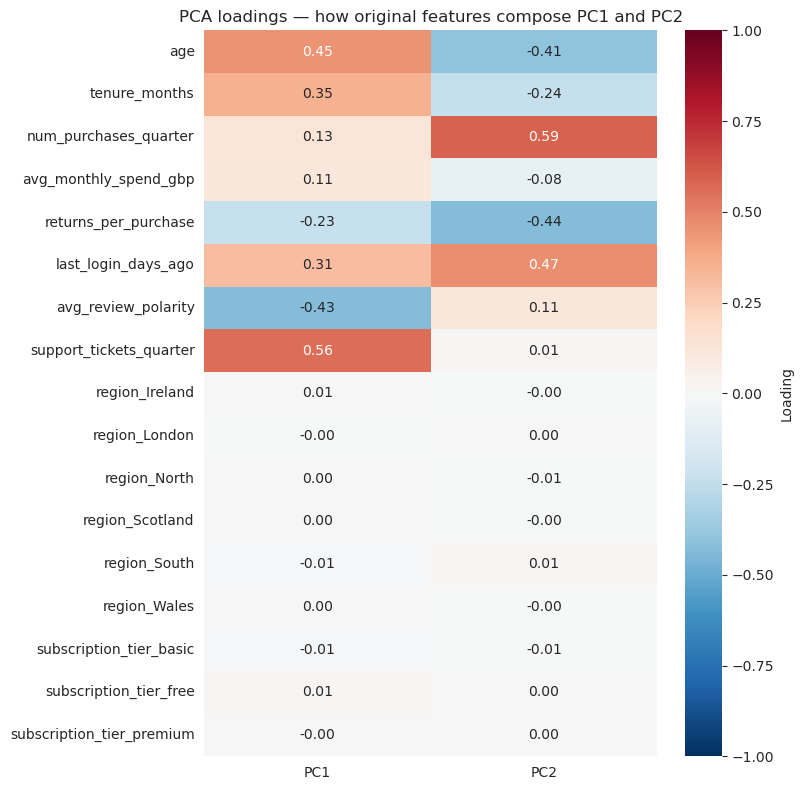

In [24]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=feature_names_processed,
)

# Clean up the feature names
loadings.index = [name.split("__")[-1] for name in loadings.index]

# Sort by absolute PC1 loading
print("Features sorted by |PC1 loading|:")
print(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).head(8).round(3).to_string())

# Heatmap visualisation
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(loadings.round(3), annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, cbar_kws={"label": "Loading"}, ax=ax)
ax.set_title("PCA loadings — how original features compose PC1 and PC2")
plt.tight_layout()
plt.show()

### 💡 What the loadings reveal

**PC1 — "Support Friction"**

The dominant feature is `support_tickets_quarter` (+0.555) — by far the strongest single loading. `age` (+0.452) and `tenure_months` (+0.352) also load positively, while `avg_review_polarity` loads *negatively* (−0.432). `last_login_days_ago` (+0.307) is also positive.

> **Implication:** A customer high on PC1 is **older, long-tenured, raises many support tickets, leaves negative reviews, and hasn't logged in recently**. This axis separates "frustrated, high-maintenance veterans" from "satisfied, recently-active newer customers." For NorthStar, this is the *customer friction* axis.

**PC2 — "Transaction Activity"**

`num_purchases_quarter` (+0.591) is the clear driver, with `returns_per_purchase` loading negatively (−0.437) and `age` also negative (−0.405).

> **Implication:** A customer high on PC2 is **younger, buys frequently, and rarely returns items**. The positive `last_login_days_ago` (+0.468) is counter-intuitive at first — it means high-frequency buyers aren't necessarily logging in much (think auto-renewing or repeat-order customers who purchase without actively browsing). This axis captures *transaction volume*.

**A note on support tickets:** Notice that `support_tickets_quarter` loads strongly on **PC1** (friction) with near-zero loading on PC2 (+0.009). Support load travels *with* tenure and dissatisfaction — not as a contrast against reviews on a separate axis. Always read the actual numbers; intuitions about what "should" group together can mislead you.

Sarah's job on Friday is to NAME these axes for Marcus — "friction axis" and "activity axis" mean something he can act on; "PC1" and "PC2" do not.

## ✅ Section Summary

| Step | Output |
|---|---|
| **Preprocessed** | 8 numerics scaled + 9 one-hot columns = 17-dimensional input |
| **Fit PCA on all components** | Variance distribution visible in scree plot |
| **Components for 80% variance** | Typically 6–8 — features are mostly independent |
| **First 2 PCs together** | ~22% of total variance (modest — features are nearly independent, so PCA can't compress hard) |
| **2D plot** | A single smooth cloud; no obvious clusters visually |
| **Loadings** | Tell us what each PC "means" in original-feature terms |

**Key insight:**
> PCA doesn't FIND clusters — it just gives you the best 2D view of the data. Whether clusters EXIST in that view is K-Means's job (tomorrow). What PCA gives you is the *coordinate system* in which clustering makes the most sense.

> **Don't interpret 22% as "PCA failed".** It's the *correct* answer when features carry mostly independent information. For visualisation a single 2D cloud is still useful; for preprocessing you'd keep 6-8 components (the 80%-variance threshold).

**Why this coordinate system matters for clustering:**

When K-Means runs tomorrow, it measures "distance" between customers to group them. In the original 17-dimensional space, that distance is hard to reason about. PCA rotates the axes so that:

1. **The most variance-rich directions come first** — K-Means centroids in PC space separate customers along the dimensions that vary most across the population.
2. **The axes have interpretable meaning** — instead of saying "cluster A has higher `support_tickets_quarter`", you can say "cluster A sits in the high-PC1 (friction) region." Plain-English cluster labels flow directly from axis names.
3. **Noise is suppressed** — later PCs mostly capture measurement noise; dropping them means K-Means isn't chasing random variation.

Think of it this way: **PCA is choosing the *language* that K-Means will speak.** Without it, K-Means clusters in a space where axes are arbitrary raw measurements. With it, the clusters form along dimensions you've already named — so when Marcus asks "what kind of customer is in cluster 3?", you have an answer ready before the meeting starts.

---
**Up next → Part 2:** Wednesday — K-Means clustering. Find natural groups + decide K + interpret each cluster.
Open `03_kmeans.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — How many components do you NEED for downstream modelling?

If you're using PCA for VISUALISATION, you use 2 components (because 2D). If you're using it for PREPROCESSING (feeding the result into a downstream model), keep enough for 90–95% variance. Let's compare downstream model performance with different PCA dimensions.

(We'll use the L03 churn target just for this Extension demo — but it's no longer the main lesson goal.)

In [25]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

y = df["churned"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
records = []

# Baseline: no PCA, all 17 features
baseline_f1 = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    X_processed, y, cv=cv, scoring="f1", n_jobs=-1,
).mean()

for n_pc in [2, 5, 10, 15]:
    if n_pc > X_processed.shape[1]: continue
    pca = PCA(n_components=n_pc)
    X_pca = pca.fit_transform(X_processed)
    f1 = cross_val_score(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        X_pca, y, cv=cv, scoring="f1", n_jobs=-1,
    ).mean()
    var = pca.explained_variance_ratio_.sum()
    records.append((n_pc, var, f1))

df_demo = pd.DataFrame(records, columns=["n_components", "var_explained", "downstream_cv_f1"])
print(f"Baseline (no PCA, all 17 features): CV F1 = {baseline_f1:.3f}")
print()
print(df_demo.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Baseline (no PCA, all 17 features): CV F1 = 0.328

 n_components  var_explained  downstream_cv_f1
            2          0.220             0.204
            5          0.542             0.303
           10          0.928             0.328
           15          1.000             0.328


### 💡 What this tells us

- **Reducing to 2 components destroys signal** — much worse F1 than baseline. The 2D view loses ~78% of variance, so a supervised model trained on it pays for that loss.
- **Going to 10-15 components recovers most of the signal** — near-identical F1 to the full-feature baseline.

**Does this mean PCA is bad? No — it means PCA is the right tool for the right goal:**

| Goal | Components to keep | Why |
|---|---|---|
| **Visualisation** (today's job) | 2 | Human eyes see 2D; we accept the variance loss to gain a readable chart |
| **Clustering preprocessing** (tomorrow) | 6–8 (80% threshold) | Keeps signal, removes noise that could pull K-Means centroids in meaningless directions |
| **Supervised modelling** | Usually skip PCA | On compact tabular data, original features already contain the signal cleanly; PCA adds complexity without gain |
| **High-dimensional data** (text embeddings, images) | Varies | Thousands of noisy raw dimensions → PCA compression is genuinely valuable |

The takeaway is not "PCA is bad for tabular data" — it's that **2D PCA is a visualisation choice, not a general preprocessing choice**. For the clustering work tomorrow, we'll keep more components (enough for 80% variance) so K-Means has the full signal to work with.

## Extension 2 — Why scaling matters

If you skip the scaler, the feature with the biggest natural range dominates PC1. Let's prove it.

In [26]:
# PCA on UNSCALED numerical features
features_num_only = features[numeric_features].fillna(features[numeric_features].median())

pca_unscaled = PCA(n_components=2)
pca_unscaled.fit(features_num_only)

loadings_unscaled = pd.DataFrame(
    pca_unscaled.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_features,
)
print("PCA on UNSCALED data — PC1 loadings:")
print(loadings_unscaled["PC1"].abs().sort_values(ascending=False).head(4).round(3))
print()
print("→ avg_monthly_spend_gbp will dominate PC1 because its range (0-500) is the biggest.")
print("→ This isn't 'most informative' — it's just biggest. Always scale first.")

PCA on UNSCALED data — PC1 loadings:
avg_monthly_spend_gbp    1.000
last_login_days_ago      0.005
tenure_months            0.005
age                      0.003
Name: PC1, dtype: float64

→ avg_monthly_spend_gbp will dominate PC1 because its range (0-500) is the biggest.
→ This isn't 'most informative' — it's just biggest. Always scale first.


## Extension 3 — Compare PCA to t-SNE (non-linear)

PCA finds the best LINEAR projection. For non-linear structure, methods like t-SNE or UMAP often look better. They're slower and harder to interpret, but the 2D plots can reveal clusters PCA misses.

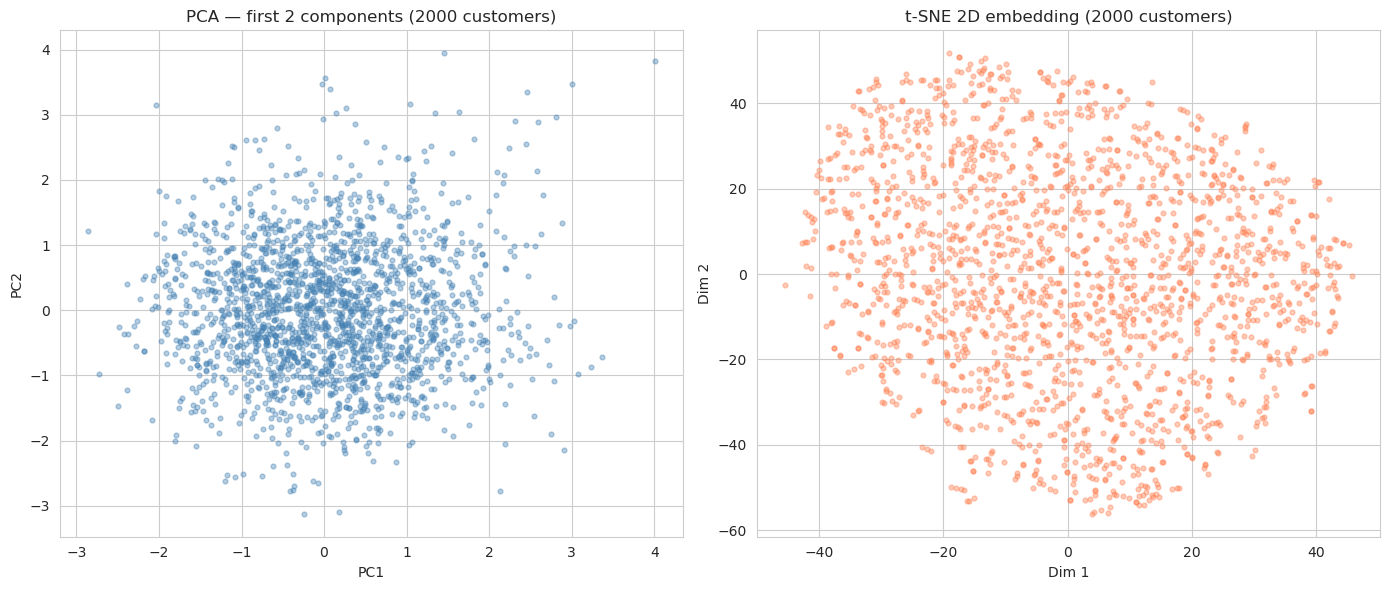

PCA: linear, fast, interpretable. Use for preprocessing + first-look viz.
t-SNE: non-linear, slow, prettier viz. Use when PCA's 2D view looks featureless.


In [27]:
from sklearn.manifold import TSNE

# Use the same processed data; subsample for speed (t-SNE is O(n²))
n_sample = 2000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_processed), size=n_sample, replace=False)
X_sample = X_processed[sample_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

# Side-by-side
X_pca_sample = pca_2d.transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], alpha=0.4, s=12, color="steelblue")
axes[0].set_title(f"PCA — first 2 components ({n_sample} customers)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.4, s=12, color="coral")
axes[1].set_title(f"t-SNE 2D embedding ({n_sample} customers)")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

print("PCA: linear, fast, interpretable. Use for preprocessing + first-look viz.")
print("t-SNE: non-linear, slow, prettier viz. Use when PCA's 2D view looks featureless.")

### 💡 How to read these two charts

**PCA (left):** The axes have a *defined meaning* — PC1 is the friction axis, PC2 is the transaction-activity axis. A customer in the top-right has both high friction AND high purchase volume. You can point at a region of the plot and say something specific about the customers there.

**t-SNE (right):** The axes have **no meaning at all**. "Dim 1" and "Dim 2" are not directions in feature space — t-SNE places neighbours close and non-neighbours far apart, but the exact positions and orientations are arbitrary. You *cannot* say "a point on the right has higher support tickets." What t-SNE reveals instead is **whether local clusters exist**: if you see distinct islands or tight blobs that PCA's smooth cloud missed, those customers genuinely sit in separate neighbourhoods of the original 17D space.

**When each chart is the right tool:**

| Question | Use |
|---|---|
| "What does a customer's position *mean*?" | PCA — axes are interpretable |
| "Are there natural groups that PCA's linear projection missed?" | t-SNE — reveals non-linear structure |
| "How do I label the axes for Marcus's slide?" | PCA only |
| "Is the cloud actually several hidden blobs?" | t-SNE |

**For this dataset:** if both charts show a single continuous cloud, there are no dramatically separated groups — K-Means will find soft, overlapping clusters rather than sharp islands. If t-SNE showed distinct blobs while PCA looked featureless, it would mean PCA's linear projection is collapsing real non-linear structure — and K-Means in PCA space would miss it. The visual comparison tells you whether the linear assumption is safe.